In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import pandas as pd
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian
import xarray as xr

import sys
sys.path.append('..')
from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

def gaussian_model(x, mu, sigma):
    y = np.exp(-0.5*(x-mu)**2 / sigma**2)
    return y/np.max(y)

In [2]:
#data_folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/"
data_folder = '../Camera_Calibrations/Ximea_Camera/'
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

In [3]:
image_size = 20
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
R, G, B, wavelength = S_F.getpixelefficiency()

cameras = ['Camera_Normal', 'Camera_Sharp', 'Camera_Broad']

R_nonsharp = 0.95*gaussian_model(wavelength, 650, 500)
G_nonsharp = 0.95*gaussian_model(wavelength, 450, 500)
B_nonsharp = 0.95*gaussian_model(wavelength, 550, 500)

R_sharp = copy(R)
G_sharp = copy(G)
B_sharp = copy(B)
B_sharp[wavelength < 500] = 0.95
B_sharp[wavelength >= 500] = 0
G_sharp[(wavelength < 500) | (wavelength > 600)] = 0
G_sharp[(wavelength < 600) & (wavelength >= 500)] = 0.95
R_sharp[wavelength < 600] = 0
R_sharp[wavelength >= 600] = 0.95

wavelength = wavelength
pixel_QYs_normal = np.vstack([B, G, R])
pixel_QYs_broad = np.vstack([B_nonsharp, G_nonsharp, R_nonsharp])
pixel_QYs_sharp = np.vstack([B_sharp, G_sharp, R_sharp])

camera_parameters = {}

for camera in cameras:
    camera_parameters[camera] = {}
    camera_parameters[camera]["gain"] = np.full((image_size, image_size), np.median(gain))
    camera_parameters[camera]["variance"] = np.full((image_size, image_size), np.median(variance))
    camera_parameters[camera]["readnoise"] = np.full((image_size, image_size), np.median(readnoise))
    camera_parameters[camera]["offset"] = np.full((image_size, image_size), np.median(offset))
    camera_parameters[camera]["rqe"] = np.full((image_size, image_size), np.median(rqe))
    camera_parameters[camera]["pixel_order"] = ['B', 'G', 'R']
    camera_parameters[camera]["pixel_order_indices"] = [0, 1, 2]
    camera_parameters[camera]["masks"] = masks
    if camera == 'Camera_Normal':
        camera_parameters[camera]["pixel_QYs"] = pixel_QYs_normal
    elif camera == 'Camera_Sharp':
        camera_parameters[camera]["pixel_QYs"] = pixel_QYs_sharp        
    else:
        camera_parameters[camera]["pixel_QYs"] = pixel_QYs_broad                

In [5]:
dyes = ['CF488A', 'ATTO 565', 'ATTO 647N', 'Cy3B']
photons_per_dye = np.array([3879, 11600, 18448, 23195])
n_bootstrap = 20000
background_photons = 40
pixel_size = 69
NA = 1.49

In [6]:
import types
smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma" :  1.5}
smoothing_function.extent =  1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [7]:
notch_filter = 'semrock-nf03-405-488-561-635e'
dichroic_mirror = 'semrock-di03-r405-488-561-635-t1-25x36'
nilered_filter = 'semrock-ff01-650-200-25'
shortpass_filter = 'semrock-bsp01-785r'
filters = [dichroic_mirror, shortpass_filter, notch_filter]

In [8]:
save_folder = r'/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250730_3Cameras_Figure1'
if not os.path.isdir(save_folder):
    os.makedirs(save_folder)

In [9]:
for i, dye in enumerate(dyes):
    for camera in cameras:
        print("Analysing dye {}".format(dye), end="\r",flush=True,)        
        MSF.test_fit_method(
                                dye,
                                filters,
                                wavelength,
                                camera_parameters[camera],
                                save_folder,
                                np.array([photons_per_dye[i]]),
                                smoothing_function=smoothing_function,
                                starting_flag="3cameras_"+str(camera)+'_',
                                n_bootstrap=n_bootstrap,
                                background_photons=background_photons,
                                NA=NA,
                                pixel_size=pixel_size,
                                cpu_fraction=1,
                                save_raw_results=True,
                                subtractx0y0=True
                            )

LM fitting: 100%|████████████████████████| 1800/1800 [00:07<00:00, 239.00task/s]


LM fitting: 100%|████████████████████████| 1800/1800 [00:07<00:00, 238.99task/s]


LM fitting: 100%|████████████████████████| 1800/1800 [00:07<00:00, 234.80task/s]


LM fitting: 100%|████████████████████████| 1800/1800 [00:07<00:00, 236.61task/s]


LM fitting: 100%|████████████████████████| 1800/1800 [00:07<00:00, 238.21task/s]


...

LM fitting: 100%|████████████████████████| 1800/1800 [00:07<00:00, 240.86task/s]


LM fitting: 100%|████████████████████████| 1800/1800 [00:07<00:00, 241.13task/s]


LM fitting: 100%|████████████████████████| 1800/1800 [00:07<00:00, 236.77task/s]


LM fitting: 100%|████████████████████████| 1800/1800 [00:07<00:00, 235.58task/s]


LM fitting: 100%|████████████████████████| 1800/1800 [00:07<00:00, 236.89task/s]


In [10]:
all_files = np.sort(os.listdir(save_folder))
Overall_XR = xr.DataArray(data=np.zeros([n_bootstrap, len(dyes), 7, 3]),
                          coords=[np.arange(n_bootstrap)+1, dyes, ['xc', 'yc', 'B', 'G', 'R', 'chi_squared', 'photons'], ['Camera_Normal', 'Camera_Sharp', 'Camera_Broad']],
                         dims=['Bootstrap_Repeat', 'Dye', 'Parameter', 'Camera'])

Overall_pd = {}
for i, dye in enumerate(dyes):
    for q, camera in enumerate(cameras):
        files = np.sort([os.path.join(save_folder, x) for x in all_files if dye in x and 'rawresults' in x and '#' not in x and camera in x])
        for j, file in enumerate(files):
            data = pl.read_csv(file)
            if i + q == 0:
                Overall_pd['dye'] = np.full_like(data['xc'].to_numpy(), dye, dtype='object')
                Overall_pd['camera'] = np.full_like(data['xc'].to_numpy(), camera, dtype='object')
            else:
                Overall_pd['dye'] = np.hstack([Overall_pd['dye'], np.full_like(data['xc'].to_numpy(), dye, dtype='object')])
                Overall_pd['camera'] = np.hstack([Overall_pd['camera'], np.full_like(data['xc'].to_numpy(), camera, dtype='object')])
            for k, parameter in enumerate(np.array(['xc', 'yc', 'A_B', 'A_G', 'A_R', 'chi_sqr', 'photons'])):
                Overall_XR[:, i, k, q] = data[parameter].to_numpy()
                if i + q + j == 0:
                    Overall_pd[parameter] = data[parameter].to_numpy()
                else:
                    Overall_pd[parameter] = np.hstack([Overall_pd[parameter], data[parameter].to_numpy()])

Overall_XR.to_netcdf(os.path.join(save_folder, 'Simulated_3camera_database.nc'))

In [11]:
pandas_df = pd.DataFrame(Overall_pd)

In [45]:
all_files = np.sort(os.listdir(save_folder))
all_files = np.sort([os.path.join(save_folder, x) for x in all_files if 'rawresults' in x])
for file in all_files:
    os.remove(file)

In [39]:
camera_sharp = pandas_df[pandas_df['camera'] == 'Camera_Sharp']

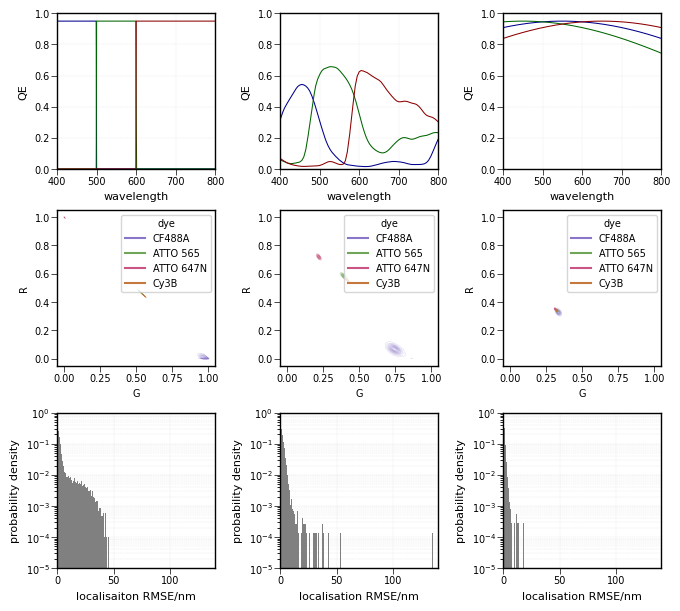

In [52]:
fig, axs = plotter.two_column_plot(ncolumns=3, nrows=3, widthratio=[1,1,1], height=6, heightratio=[1,1,1])

cs = ["#8975ca",
      "#71a659",
      "#cb5582",
      "#c5783e"]

axs[0, 0] = plotter.line_plot(axs=axs[0, 0], x=wavelength, y=B_sharp, color='darkblue')
axs[0, 0] = plotter.line_plot(axs=axs[0, 0], x=wavelength, y=G_sharp, color='darkgreen')
axs[0, 0] = plotter.line_plot(axs=axs[0, 0], x=wavelength, y=R_sharp, color='darkred', yaxislabel='QE', xaxislabel='wavelength')

axs[0, 1] = plotter.line_plot(axs=axs[0, 1], x=wavelength, y=B, color='darkblue')
axs[0, 1] = plotter.line_plot(axs=axs[0, 1], x=wavelength, y=G, color='darkgreen')
axs[0, 1] = plotter.line_plot(axs=axs[0, 1], x=wavelength, y=R, color='darkred', yaxislabel='QE', xaxislabel='wavelength')

axs[0, 2] = plotter.line_plot(axs=axs[0, 2], x=wavelength, y=B_nonsharp, color='darkblue')
axs[0, 2] = plotter.line_plot(axs=axs[0, 2], x=wavelength, y=G_nonsharp, color='darkgreen')
axs[0, 2] = plotter.line_plot(axs=axs[0, 2], x=wavelength, y=R_nonsharp, color='darkred', yaxislabel='QE', xaxislabel='wavelength')

camera_sharp_plot = camera_sharp[camera_sharp['chi_sqr'] < 3]
axs[1, 0] = sns.kdeplot(camera_sharp_plot, x="A_G", y="A_R", hue="dye", levels=20, ax=axs[1,0], palette=cs, linewidths=0.1, common_norm=False)
axs[1, 1] = sns.kdeplot(camera_bayer, x="A_G", y="A_R", hue="dye", levels=20, ax=axs[1,1], palette=cs, linewidths=0.1, common_norm=False)
axs[1, 2] = sns.kdeplot(camera_broad, x="A_G", y="A_R", hue="dye", levels=20, ax=axs[1,2], palette=cs, linewidths=0.1, common_norm=False)

for i in np.arange(3):
    axs[0, i].set_ylim([0, 1])
    axs[0, i].set_xlim([400, 800])

for i in np.arange(3):
    axs[1, i].set_ylim([-0.05, 1.05])
    axs[1, i].set_xlim([-0.05, 1.05])
    axs[1, i].set_ylabel('R')
    axs[1, i].set_xlabel('G')

axs[2, 0] = plotter.histogram_plot(axs=axs[2,0], 
                                   data=np.abs(camera_sharp['xc'])*69, bins=np.histogram_bin_edges(np.abs(camera_sharp['xc'])*69, 'fd'),
                                  xaxislabel='localisaiton RMSE/nm')
axs[2, 1] = plotter.histogram_plot(axs=axs[2,1], 
                                   data=np.abs(camera_bayer['xc'])*69, bins=np.histogram_bin_edges(np.abs(camera_bayer['xc'])*69, 'fd'),
                                  xaxislabel='localisation RMSE/nm')
axs[2, 2] = plotter.histogram_plot(axs=axs[2,2], 
                                   data=np.abs(camera_broad['xc'])*69, bins=np.histogram_bin_edges(np.abs(camera_broad['xc'])*69, 'fd'),
                                  xaxislabel='localisation RMSE/nm')

for i in np.arange(3):
    axs[2, i].set_xlim([0, 140])
    axs[2, i].set_yscale('log')
    axs[2, i].set_ylim([1e-5, 1])


folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/Figure1'
plt.savefig(os.path.join(folder, 'Exemplar_Camera_QEs.svg'), dpi=600, format='svg')